# General EDA & Cleaning — Blue Jays MLB Pitching Dataset

**Purpose:** This notebook establishes a clean, Blue-Jays-only base dataset that is shared across all three research questions:
1. Does pitcher performance degrade as games progress? *(fatigue)*
2. Can the next pitch type be predicted from game context? *(predictability)*
3. Which pitching factors drive optimal performance? *(effectiveness)*

Every cleaning and transformation step is documented here. Each question's own notebook should import the cleaned DataFrame produced at the end of this one, rather than re-doing these steps independently.

**Data source:** StatCast advanced tracking (Hawk-Eye optical system), official MLB feed.  
**Scope:** Postseason only — September 30 to November 1, 2025.

---
## Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent plot style across all cells
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

---
## Step 1 — Load the Dataset & Initial Structure Audit

Before changing anything, we need to understand what we are working with:
- How many rows and columns does the raw data have?
- What data type did pandas infer for each column? (mistyped columns cause silent errors later)
- Are there any fully duplicated rows?
- What do the first few records look like?
- What are the min/max/mean values for every numeric column? (extreme values indicate outliers or encoding errors)

This step is **read-only** — nothing is dropped or modified yet.

In [57]:
# Load the raw CSV. low_memory=False prevents pandas from guessing column types
# mid-file, which can cause mixed-type columns to be silently cast to object.
df_raw = pd.read_csv("Data_MLB_2025.csv", low_memory=False)

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Rows: 14,096
Columns: 95


In [58]:
# Inferred data types — anything that should be numeric but shows as 'object'
# is a red flag (usually means mixed values or string-encoded numbers).
df_raw.dtypes

game_year               int64
game_date                 str
player_name               str
pitcher                 int64
batter                  int64
                       ...   
spin_axis             float64
delta_home_win_exp    float64
delta_run_exp         float64
bat_speed             float64
swing_length          float64
Length: 95, dtype: object

In [59]:
# Check for fully duplicated rows (every column value identical).
# A non-zero result would indicate data ingestion or export errors.
dup_count = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")

Fully duplicated rows: 0


In [60]:
# Preview the first five rows to visually confirm the structure.
# This is the most direct way to catch import-level issues
# (e.g., header shifted by one column, values in wrong columns).
df_raw.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [61]:
# Descriptive statistics for every numeric column.
# Pay attention to min/max: physically impossible values will appear here
# before we do any cleaning (e.g., spin_rate == 0, negative extension).
df_raw.describe()

,game_year,pitcher,batter,balls,strikes,inning,at_bat_number,pitch_number,release_speed,release_pos_x,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
count,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,...,14096.000000,14096.00000,14096.000000,14096.000000,14096.000000,14089.000000,14096.000000,14096.000000,6704.000000,6704.000000
mean,2025.0,654432.648127,646575.503689,0.872375,0.916359,5.273624,40.607406,2.925227,90.682740,-0.796971,...,2.110031,1.94431,2.223184,2.057463,2.110031,176.305203,0.000167,-0.002535,69.569391,7.244824
std,0.0,60782.502545,49297.380592,0.968588,0.829502,3.027925,25.720786,1.741043,6.008374,1.893833,...,2.523059,2.20987,2.625899,2.334641,2.523059,74.953615,0.027601,0.222230,9.545128,1.054472
min,2025.0,453286.000000,457759.000000,0.000000,0.000000,1.000000,1.000000,1.000000,69.200000,-4.330000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.509000,-0.530000,2.000000,0.500000
25%,2025.0,608718.000000,608701.000000,0.000000,0.000000,3.000000,20.000000,1.000000,86.200000,-2.160000,...,0.000000,0.00000,0.000000,0.000000,0.000000,132.000000,0.000000,-0.063000,67.100000,6.600000
50%,2025.0,666200.000000,664023.000000,1.000000,1.000000,5.000000,39.000000,3.000000,91.600000,-1.600000,...,1.000000,1.00000,1.000000,1.000000,1.000000,201.000000,0.000000,-0.039000,71.200000,7.300000
75%,2025.0,682120.000000,676391.000000,1.000000,2.000000,7.000000,59.000000,4.000000,95.700000,1.040000,...,3.000000,3.00000,3.000000,3.000000,3.000000,222.000000,0.000000,0.039000,74.600000,8.000000
max,2025.0,813349.000000,807799.000000,3.000000,2.000000,18.000000,153.000000,13.000000,104.500000,4.100000,...,13.000000,13.00000,13.000000,13.000000,13.000000,360.000000,0.412000,2.696000,87.600000,10.400000


---
## Step 2 — Filter to Blue Jays Pitching Records Only

The raw dataset contains **all** pitches from all postseason games — including games the Blue Jays did not play in, and at-bats where the Blue Jays were the *batting* team (meaning an *opponent* was pitching).

We need only the pitches thrown **by Blue Jays pitchers**, so we apply two filters in sequence:

1. **Game filter:** Keep only games where TOR was either the home or away team.
2. **Half-inning filter:** Within those games, keep only the half-innings where TOR is fielding (i.e., the opposing team is batting).
   - When TOR is the **home** team → they field in the **Top** of each inning (`inning_topbot == 'Top'`)
   - When TOR is the **away** team → they field in the **Bottom** of each inning (`inning_topbot == 'Bot'`)

**Note on `game_type`:** The midterm roadmap includes a filter for `game_type == 'R'` (regular season). However, this dataset covers the postseason only — every record has `game_type == 'P'`. Applying that filter would drop the entire dataset. We document this as a known scope limitation and skip that filter.

In [62]:
# --- Confirm game_type values present in the dataset ---
# Expected: only 'P' (postseason). If 'R' appears, the game_type filter
# from the roadmap would then be meaningful.
print("game_type values:", df_raw["game_type"].unique())
print()

# --- Step 1: keep only games TOR participated in ---
tor_games = df_raw[
    (df_raw["home_team"] == "TOR") | (df_raw["away_team"] == "TOR")
].copy()

print(f"Rows in TOR games (all halves): {len(tor_games):,}")
print(f"Unique games: {tor_games['game_pk'].nunique()}")

game_type values: <StringArray>
['F', 'D', 'L', 'W']
Length: 4, dtype: str

Rows in TOR games (all halves): 5,544
Unique games: 18


In [63]:
# --- Step 2: isolate half-innings where TOR is the fielding team ---
# The inning_topbot column tells us which half-inning we are in.
# When TOR is home, they pitch in the Top half (away team bats).
# When TOR is away, they pitch in the Bottom half (home team bats).
df = tor_games[
    ((tor_games["home_team"] == "TOR") & (tor_games["inning_topbot"] == "Top"))
    | ((tor_games["away_team"] == "TOR") & (tor_games["inning_topbot"] == "Bot"))
].copy()

# Reset index so row numbers are clean and sequential from this point on.
df = df.reset_index(drop=True)

print(f"Blue Jays pitching rows: {len(df):,}")
print(f"Unique pitchers: {df['pitcher'].nunique()}")
print(f"Unique games: {df['game_pk'].nunique()}")
print()
print("Pitchers in the dataset:")
print(df["player_name"].unique())

Blue Jays pitching rows: 2,788
Unique pitchers: 15
Unique games: 18

Pitchers in the dataset:
<StringArray>
['Domínguez, Seranthony',        'Gausman, Kevin',         'Hoffman, Jeff',
       'Little, Brendon',        'Varland, Louis',        'Bruihl, Justin',
       'Fisher, Braydon',       'Fluharty, Mason',           'Lauer, Eric',
          'Nance, Tommy',        'Yesavage, Trey',         'Bieber, Shane',
     'Rodríguez, Yariel',        'Bassitt, Chris',         'Scherzer, Max']
Length: 15, dtype: str


---
## Step 3 — Drop Deprecated & Fully-Empty Columns

Several columns in the StatCast schema are **legacy fields** that were retired from the tracking system. They appear in the CSV header but contain no values. Keeping them wastes memory and causes confusion when inspecting the DataFrame.

We also need to fix a **structural parsing issue**: the column `fielder_2` appears **three times** in the raw CSV (at positions 45, 64, and 65). Pandas renames duplicates automatically to `fielder_2.1` and `fielder_2.2`. We keep only the first occurrence.

**Columns to drop:**
| Column | Reason |
|---|---|
| `spin_dir` | Fully empty — retired StatCast field |
| `spin_rate_deprecated` | Fully empty — replaced by `release_spin_rate` |
| `break_angle_deprecated` | Fully empty — retired field |
| `break_length_deprecated` | Fully empty — retired field |
| `tfs_deprecated` | Fully empty — retired timestamp field |
| `tfs_zulu_deprecated` | Fully empty — retired timestamp field |
| `umpire` | Fully empty — not populated in postseason feed |
| `sv_id` | Fully empty — legacy video ID field |
| `fielder_2.1` | Duplicate column (CSV parsing artifact) |
| `fielder_2.2` | Duplicate column (CSV parsing artifact) |

In [64]:
# --- Identify columns that are 100% null ---
# We confirm programmatically rather than hard-coding, so this step
# is robust if the CSV is ever updated with a slightly different schema.
fully_empty = df.columns[df.isnull().all()].tolist()
print(f"Fully empty columns ({len(fully_empty)}):")
for col in fully_empty:
    print(f"  {col}")

Fully empty columns (8):
  spin_dir
  spin_rate_deprecated
  break_angle_deprecated
  break_length_deprecated
  tfs_deprecated
  tfs_zulu_deprecated
  umpire
  sv_id


In [65]:
# --- Identify duplicate column names (pandas renames them with .1, .2 suffixes) ---
duplicate_cols = [col for col in df.columns if col.endswith(".1") or col.endswith(".2")]
print(f"Duplicate columns to remove: {duplicate_cols}")

Duplicate columns to remove: ['fielder_2.1', 'fielder_2.2']


In [66]:
# --- Drop all fully-empty and duplicate columns in one pass ---
cols_to_drop = fully_empty + duplicate_cols
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns remaining after drop: {df.shape[1]}")
print(f"Rows unchanged: {df.shape[0]:,}")

Columns remaining after drop: 85
Rows unchanged: 2,788


---
## Step 4 — Assess & Handle Missing Values

Not all missing values mean the same thing. In a pitch-level dataset like this, missing values fall into three distinct categories:

| Category | Examples | Why they are missing | Action |
|---|---|---|---|
| **Structurally sparse** | `events`, `launch_speed`, `woba_value`, `hit_distance_sc`, `estimated_woba_using_speedangle`, `hc_x`, `hc_y`, `bb_type` | Only populated when the pitch ends an at-bat with a ball in play. Nulls on strikes, balls, and foul balls are **expected**. | Leave as-is. Each question's notebook filters for the rows it needs. |
| **Swing-only** | `bat_speed`, `swing_length` | Only recorded when the batter swings. Nulls = no swing. | Leave as-is. |
| **Base runners** | `on_1b`, `on_2b`, `on_3b` | Null means the base is **empty**, not that data is missing. | Fill with `0`. |
| **Core mechanics** | `release_speed`, `release_spin_rate`, `plate_x`, `plate_z`, `effective_speed` | True tracking failures — the Hawk-Eye system lost the ball. | Drop affected rows (very few, <0.1%). |

**Important:** We do **not** impute structurally sparse columns here. Imputing an average `launch_speed` for a pitch that was never put in play would be statistically nonsensical and would corrupt any question that relies on those values.

In [67]:
# --- Full missing value report sorted by % missing ---
# This gives us a ranked list to reason about each column.
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

# Only show columns that actually have missing values
missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_pct
on_3b,2599,93.22
estimated_ba_using_speedangle,2340,83.93
launch_speed_angle,2340,83.93
hc_y,2337,83.82
hc_x,2337,83.82
bb_type,2337,83.82
on_2b,2315,83.03
hit_location,2188,78.48
estimated_woba_using_speedangle,2092,75.04
woba_denom,2090,74.96


In [68]:
# --- Fill base runner columns with 0 ---
# on_1b, on_2b, on_3b store the batter ID of whoever is on that base.
# When the column is null, it means the base is unoccupied — not missing data.
# We replace null with 0 so downstream boolean checks work cleanly
# (e.g., runners_on = (on_1b > 0) | (on_2b > 0) | (on_3b > 0)).
base_runner_cols = ["on_1b", "on_2b", "on_3b"]
df[base_runner_cols] = df[base_runner_cols].fillna(0)

print("Base runner nulls after fill:")
print(df[base_runner_cols].isnull().sum())

Base runner nulls after fill:
on_1b    0
on_2b    0
on_3b    0
dtype: int64


In [69]:
# --- Drop rows where core tracking mechanics are missing ---
# These columns are required for every analysis question. A pitch with no
# release_speed or plate location cannot contribute meaningful information
# and represents a Hawk-Eye sensor failure, not a real pitch event.
core_cols = ["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]

rows_before = len(df)
df.dropna(subset=core_cols, inplace=True)
rows_after = len(df)

print(f"Rows dropped due to missing core mechanics: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after:,}")

Rows dropped due to missing core mechanics: 0
Rows remaining: 2,788


---
## Step 5 — Fix Data Types

Pandas read some columns as the wrong type:

- **`game_date`** was read as a plain string (`object`). Converting it to `datetime` unlocks date arithmetic (e.g., computing rest days, grouping by week).
- **Categorical columns** (pitch type, handedness, fielding alignment, etc.) are stored as strings but have a small fixed set of possible values. Converting them to `category` dtype reduces memory usage and makes `groupby` operations faster.

We do **not** touch numeric columns — pandas already inferred `int64` or `float64` for all of them correctly.

In [70]:
# --- Convert game_date from string to datetime ---
# format='%Y-%m-%d' is explicit — avoids ambiguity if pandas auto-detects
# formats differently on different OS locales.
df["game_date"] = pd.to_datetime(df["game_date"], format="%Y-%m-%d")

print(f"game_date dtype: {df['game_date'].dtype}")
print(f"Date range: {df['game_date'].min().date()} → {df['game_date'].max().date()}")

game_date dtype: datetime64[us]
Date range: 2025-10-04 → 2025-11-01


In [71]:
# --- Cast categorical columns to 'category' dtype ---
# These columns have a small, fixed set of values (e.g., 'L'/'R' for stand).
# The 'category' dtype stores each unique string once and uses integer codes
# internally, cutting memory and speeding up groupby operations.
cat_cols = [
    "pitch_name",          # pitch type name (e.g., '4-Seam Fastball')
    "pitch_type",          # short code (e.g., 'FF')
    "stand",               # batter handedness: 'L' or 'R'
    "p_throws",            # pitcher hand: 'L' or 'R'
    "inning_topbot",       # half-inning: 'Top' or 'Bot'
    "description",         # pitch outcome description (e.g., 'Ball', 'Called Strike')
    "events",              # at-bat ending event (null on non-terminal pitches)
    "bb_type",             # batted ball type: 'fly_ball', 'ground_ball', etc.
    "if_fielding_alignment",  # infield shift alignment
    "of_fielding_alignment",  # outfield shift alignment
    "type",                # pitch result category: 'S' (strike), 'B' (ball), 'X' (in play)
    "game_type",           # 'P' for postseason throughout this dataset
]

# Only cast columns that actually exist after Step 3 drops
cat_cols_present = [c for c in cat_cols if c in df.columns]

for col in cat_cols_present:
    df[col] = df[col].astype("category")

print(f"Converted {len(cat_cols_present)} columns to 'category' dtype.")
print()

# Confirm the unique values for the most important categoricals
for col in ["stand", "p_throws", "inning_topbot", "type"]:
    print(f"{col}: {df[col].cat.categories.tolist()}")

Converted 12 columns to 'category' dtype.

stand: ['L', 'R']
p_throws: ['L', 'R']
inning_topbot: ['Bot', 'Top']
type: ['B', 'S', 'X']


---
## Step 6 — Remove Outliers (IQR Filtering on Core Mechanics)

The StatCast Hawk-Eye system derives some metrics (e.g., spin rate) from optical tracking and can produce physically impossible values when the system loses track of the ball or misidentifies it:

- **`release_spin_rate == 0`** — no pitch has zero spin; this is a sensor dropout.
- **`launch_speed > 120 mph`** — the documented MLB record is ~122 mph, but values well above 110 are likely encoding errors in postseason data.
- **Negative `release_extension`** — extension is the distance from the rubber to the release point; it cannot be negative.

We use **IQR filtering** applied **per pitch type group** to flag and remove statistical extremities. Applying IQR across all pitch types pooled together would be incorrect — a 95 mph reading is normal for a 4-Seam Fastball but extreme for a Curveball. Grouping by `pitch_name` ensures each pitch type's outlier bounds are calibrated to that pitch type's natural range.

**IQR method:**
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Rows outside these bounds on **any** of the target columns are removed.

In [72]:
# --- Preview potential outlier rows before removing them ---
# This makes the cleaning step transparent and auditable.

print("=== release_spin_rate == 0 ===")
print(df[df["release_spin_rate"] == 0][["player_name", "pitch_name", "release_spin_rate", "release_speed"]].head(10))
print()

print("=== Negative release_extension ===")
if "release_extension" in df.columns:
    neg_ext = df[df["release_extension"] < 0]
    print(neg_ext[["player_name", "pitch_name", "release_extension"]].head(10))
    print(f"Count: {len(neg_ext)}")
else:
    print("release_extension column not present.")
print()

print("=== launch_speed extremes ===")
if "launch_speed" in df.columns:
    high_launch = df[df["launch_speed"] > 115].dropna(subset=["launch_speed"])
    print(high_launch[["player_name", "pitch_name", "launch_speed", "launch_angle"]].head(10))
    print(f"Count: {len(high_launch)}")

=== release_spin_rate == 0 ===
Empty DataFrame
Columns: [player_name, pitch_name, release_spin_rate, release_speed]
Index: []

=== Negative release_extension ===
Empty DataFrame
Columns: [player_name, pitch_name, release_extension]
Index: []
Count: 0

=== launch_speed extremes ===
          player_name     pitch_name  launch_speed  launch_angle
308     Bieber, Shane  Knuckle Curve         116.3           7.0
1672  Fisher, Braydon         Slider         116.2          17.0
2451   Yesavage, Trey         Slider         117.3          17.0
Count: 3


In [73]:
# --- IQR outlier removal per pitch type ---
# We apply this to the core mechanics that directly feed all three questions.
# Columns with structural sparsity (launch_speed, woba_value, etc.) are
# excluded here — their outlier handling belongs in each question's notebook
# because they are only relevant for balls-in-play subsets.

mechanics_cols = [
    "release_speed",
    "release_spin_rate",
    "effective_speed",
]

# Add release_extension only if the column exists in this dataset version
if "release_extension" in df.columns:
    mechanics_cols.append("release_extension")

def iqr_mask(group, col):
    """Returns a boolean mask that is True for non-outlier rows within a group."""
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (group[col] >= lower) & (group[col] <= upper)

rows_before = len(df)

# Build a combined mask: a row must pass IQR on ALL mechanics columns
# within its own pitch_name group to be retained.
keep_mask = pd.Series(True, index=df.index)

for col in mechanics_cols:
    col_mask = df.groupby("pitch_name", observed=True).apply(
        lambda g: iqr_mask(g, col)
    )
    # Flatten the multi-index result back to align with df.index
    col_mask = col_mask.reset_index(level=0, drop=True).reindex(df.index)
    keep_mask &= col_mask

df = df[keep_mask].copy().reset_index(drop=True)

rows_after = len(df)
print(f"Rows removed as outliers: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after:,}")

Rows removed as outliers: 166
Rows remaining: 2,622


---
## Step 7 — Engineer Shared Features

Three engineered features are referenced across multiple research questions. Creating them here once, on the cleaned base dataset, ensures all questions use an identical definition.

| Feature | Used by | Description |
|---|---|---|
| `cum_pitch_count` | Q1, Q2 | Running count of pitches thrown by a pitcher within a game. Resets to 1 at the start of each new game or each new pitcher. Enables sequential analysis of within-game fatigue. |
| `game_phase` | Q1 | Categorises each pitch into Early (innings 1–3), Mid (4–6), or Late (7+). Allows comparison of performance segments without treating inning as a continuous variable. |
| `score_diff` | Q2, Q3 | Difference between the batting team's score and the fielding team's score from the pitcher's perspective (bat_score − fld_score). Positive = pitcher's team is losing; negative = pitcher's team is winning. Captures game pressure/leverage. |

In [74]:
# --- Cumulative pitch count per pitcher per game ---
# groupby(['game_pk', 'pitcher']) creates one group per pitcher-game combination.
# cumcount() assigns 0, 1, 2, ... within each group, ordered by the current
# row sequence (which is already sorted by game then at-bat then pitch number
# from the raw StatCast export). We add 1 so counting starts at 1, not 0.
df["cum_pitch_count"] = (
    df.groupby(["game_pk", "pitcher"]).cumcount() + 1
)

print("Cumulative pitch count summary:")
print(df["cum_pitch_count"].describe().round(1))

Cumulative pitch count summary:
count    2622.0
mean       26.2
std        24.2
min         1.0
25%         7.0
50%        16.0
75%        43.0
max       104.0
Name: cum_pitch_count, dtype: float64


In [75]:
# --- Game phase (Early / Mid / Late) ---
# Using pd.cut with explicit bins and labels converts a continuous inning number
# into an ordinal category. The bins (0, 3, 6, inf] translate to:
#   Early = innings 1–3 (first time through the lineup)
#   Mid   = innings 4–6 (second time through)
#   Late  = inning 7+   (bullpen territory / high-leverage situations)
df["game_phase"] = pd.cut(
    df["inning"],
    bins=[0, 3, 6, float("inf")],
    labels=["Early", "Mid", "Late"],
    right=True   # intervals are (left, right], so (0,3] = innings 1,2,3
)

print("Pitch counts by game phase:")
print(df["game_phase"].value_counts().sort_index())

Pitch counts by game phase:
game_phase
Early    875
Mid      779
Late     968
Name: count, dtype: int64


In [76]:
# --- Score differential (from pitcher's team perspective) ---
# bat_score  = runs scored by the team currently batting (opposing team)
# fld_score  = runs scored by the team currently fielding (Blue Jays)
# score_diff = bat_score - fld_score
#   > 0 → Blue Jays are losing (pitcher under pressure to minimise damage)
#   = 0 → tied game
#   < 0 → Blue Jays are winning (pitcher can pitch more conservatively)
df["score_diff"] = df["bat_score"] - df["fld_score"]

print("Score differential distribution:")
print(df["score_diff"].describe().round(2))

Score differential distribution:
count    2622.00
mean       -1.20
std         3.26
min       -12.00
25%        -2.00
50%         0.00
75%         0.00
max         7.00
Name: score_diff, dtype: float64


---
## Step 8 — General EDA Visualizations

With a clean base dataset in hand, we produce five overview plots that give a holistic picture of the data **before** any question-specific analysis. These plots serve as a reference point and a quality check — if something looks wrong here, the earlier cleaning steps should be revisited.

1. **Pitch type distribution** — what mix of pitches do Blue Jays pitchers throw?
2. **Game date coverage** — confirms we are working with postseason data and shows game density over time.
3. **Missing value heatmap** — visual map of where nulls remain after cleaning (structurally sparse columns will still show nulls — that is expected).
4. **Pitcher workload** — how many pitches did each pitcher throw across the postseason?
5. **Core numeric distributions** — histograms of the four most important pitching mechanics, with pre/post outlier-removal shapes.

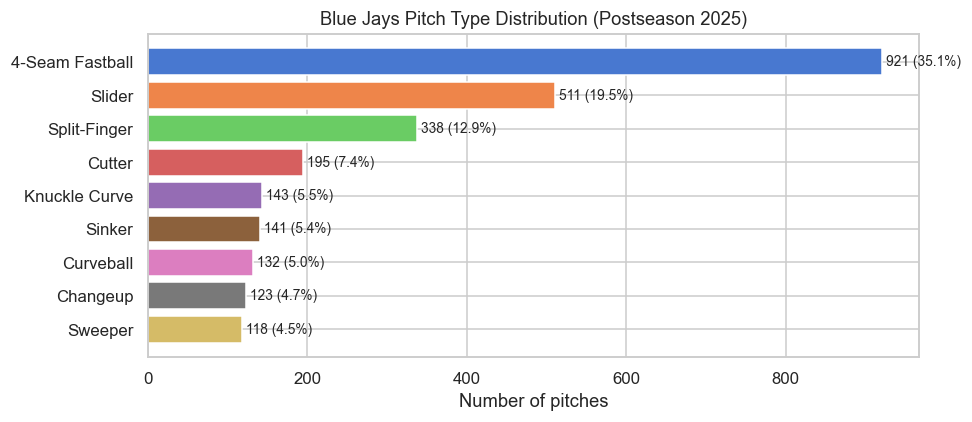

In [77]:
# --- Plot 1: Pitch type distribution ---
# Shows the overall pitch mix for Blue Jays pitchers in the postseason.
# A heavily skewed distribution (e.g., one pitch type dominates) could
# affect the predictability analysis in Question 2.

pitch_counts = df["pitch_name"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(pitch_counts.index, pitch_counts.values, color=sns.color_palette("muted", len(pitch_counts)))

# Annotate each bar with the count and percentage
total = pitch_counts.sum()
for bar, count in zip(bars, pitch_counts.values):
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        f"{count} ({count/total*100:.1f}%)",
        va="center", fontsize=9
    )

ax.set_xlabel("Number of pitches")
ax.set_title("Blue Jays Pitch Type Distribution (Postseason 2025)")
ax.invert_yaxis()  # most common pitch at the top
plt.tight_layout()
plt.show()

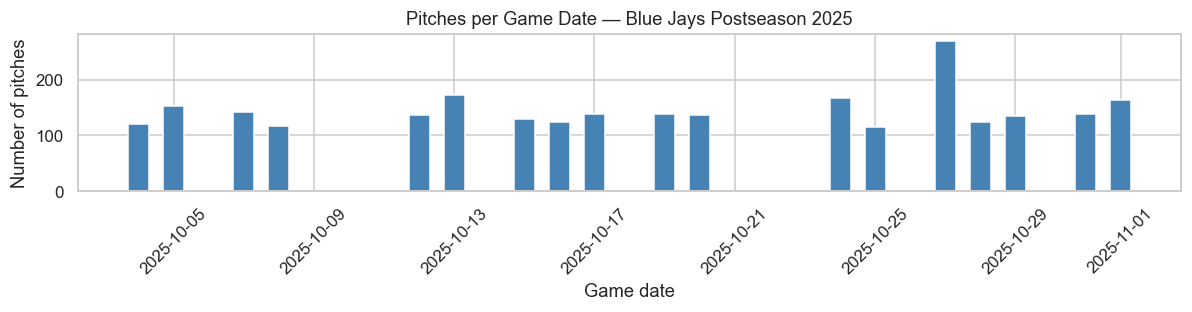

Total games: 18
Date range: 2025-10-04 → 2025-11-01


In [78]:
# --- Plot 2: Game date coverage ---
# Shows when each game took place. Gaps indicate rest days between series.
# The postseason structure (Wild Card → Division → Championship → World Series)
# can create unequal intervals between games that could affect fatigue analysis.

pitches_per_date = df.groupby("game_date").size()

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(pitches_per_date.index, pitches_per_date.values, width=0.6, color="steelblue")
ax.set_xlabel("Game date")
ax.set_ylabel("Number of pitches")
ax.set_title("Pitches per Game Date — Blue Jays Postseason 2025")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Total games: {df['game_pk'].nunique()}")
print(f"Date range: {df['game_date'].min().date()} → {df['game_date'].max().date()}")

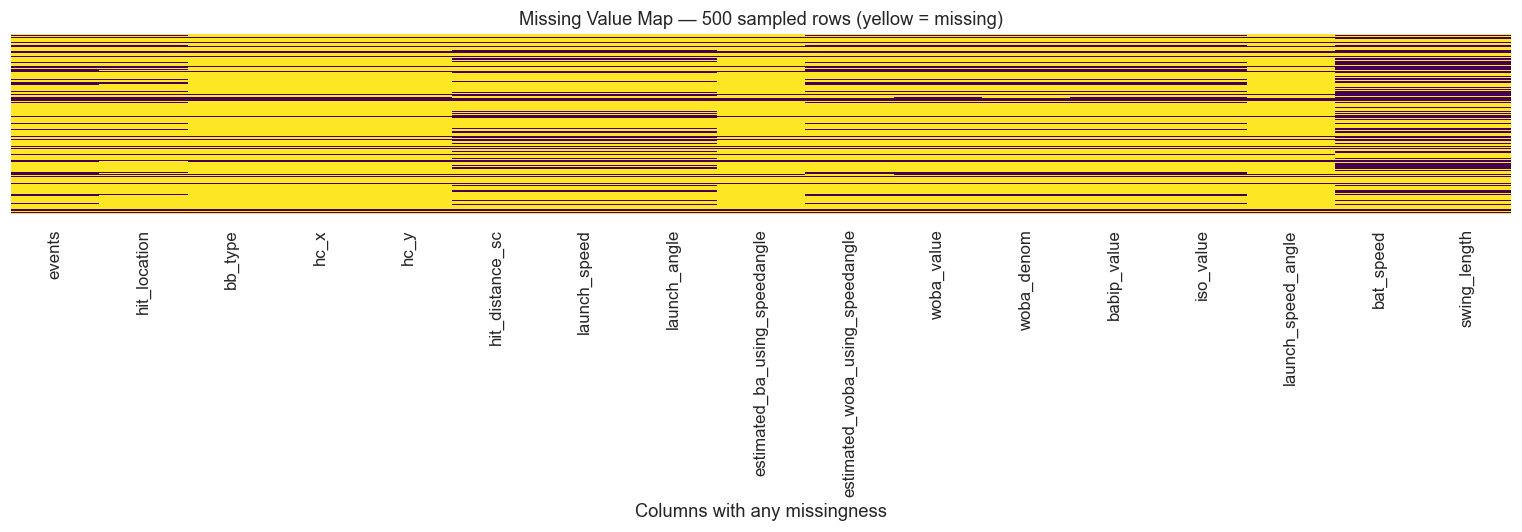


Columns shown: 17


In [79]:
# --- Plot 3: Missing value heatmap ---
# Yellow = missing, purple = present. After our cleaning:
#   - Core mechanics columns should be fully purple (0% missing).
#   - Outcome columns (events, launch_speed, woba_value, etc.) will still show
#     yellow — this is correct because they are only populated for balls in play.
# If core mechanics columns show any yellow here, revisit Step 4.

# Select columns with any remaining missingness to keep the plot readable
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Sample rows for performance (heatmap over 2000+ rows is very slow)
sample_size = min(500, len(df))
sample_idx = df.sample(sample_size, random_state=42).index

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    df.loc[sample_idx, cols_with_missing].isnull(),
    cbar=False, yticklabels=False, ax=ax,
    cmap="viridis"
)
ax.set_title(f"Missing Value Map — {sample_size} sampled rows (yellow = missing)")
ax.set_xlabel("Columns with any missingness")
plt.tight_layout()
plt.show()

print(f"\nColumns shown: {len(cols_with_missing)}")

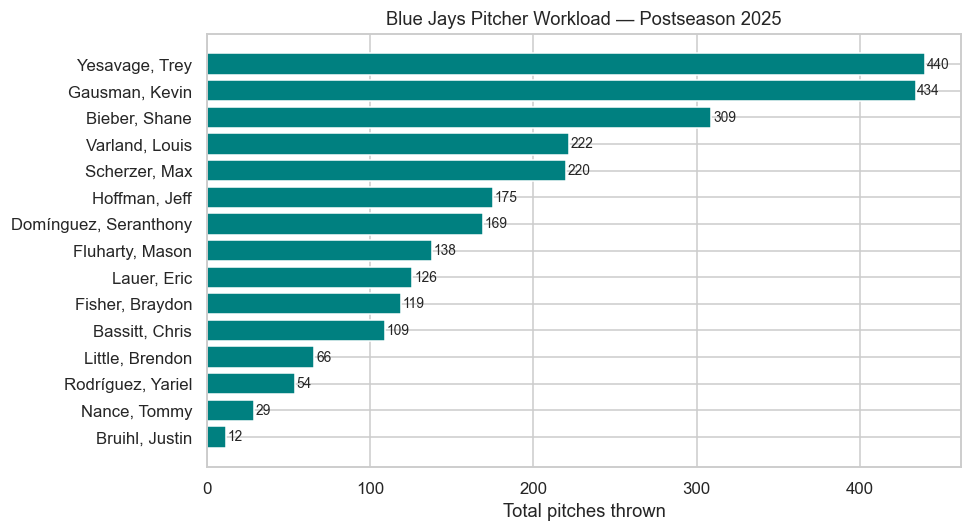

In [80]:
# --- Plot 4: Pitcher workload (total pitches per pitcher) ---
# This tells us how much data we have per pitcher. Pitchers with very few
# pitches (e.g., appeared in only one game) will have limited statistical
# power in per-pitcher analyses — important context for Question 1.

workload = (
    df.groupby("player_name", observed=True)
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(workload.index, workload.values, color="teal")

for bar, val in zip(bars, workload.values):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(val), va="center", fontsize=9
    )

ax.set_xlabel("Total pitches thrown")
ax.set_title("Blue Jays Pitcher Workload — Postseason 2025")
plt.tight_layout()
plt.show()

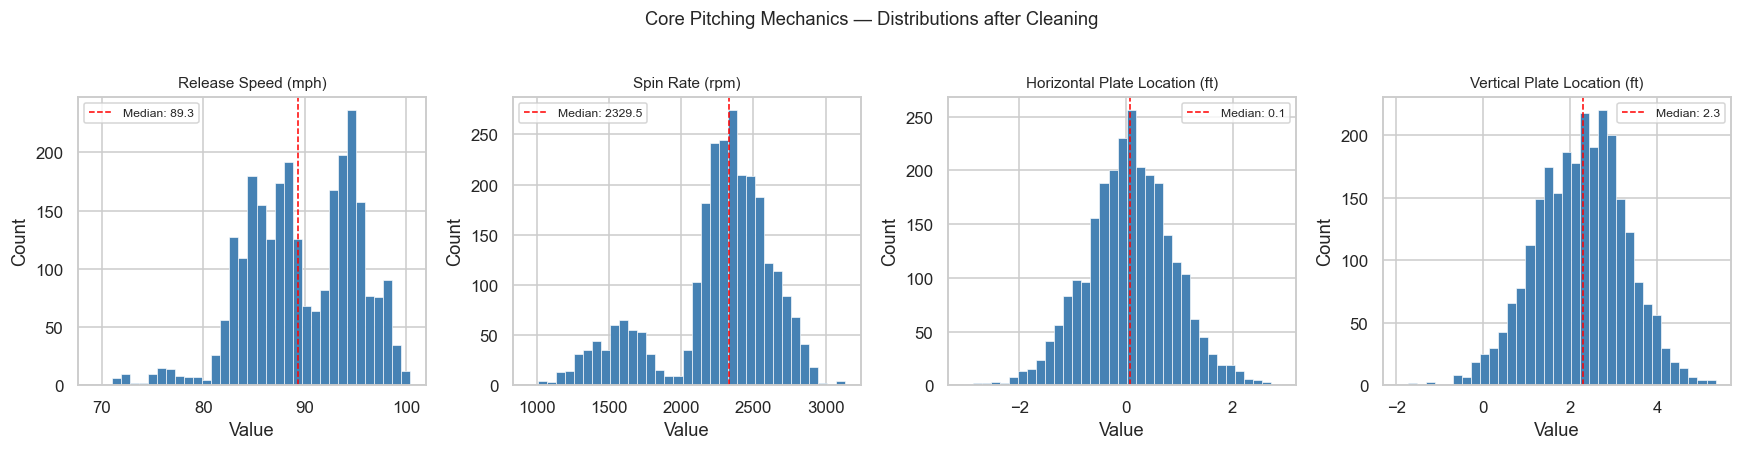

In [81]:
# --- Plot 5: Distributions of core pitching mechanics ---
# These four variables are used in all three research questions.
# After IQR filtering, distributions should be roughly unimodal
# (multi-modal is expected for release_speed because different pitch types
# naturally cluster at different speeds — that is correct, not an error).

core_mechanics = [
    ("release_speed",     "Release Speed (mph)"),
    ("release_spin_rate", "Spin Rate (rpm)"),
    ("plate_x",           "Horizontal Plate Location (ft)"),
    ("plate_z",           "Vertical Plate Location (ft)"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (col, label) in zip(axes, core_mechanics):
    ax.hist(df[col].dropna(), bins=35, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    # Add a vertical line at the median for reference
    median_val = df[col].median()
    ax.axvline(median_val, color="red", linestyle="--", linewidth=1, label=f"Median: {median_val:.1f}")
    ax.legend(fontsize=8)

fig.suptitle("Core Pitching Mechanics — Distributions after Cleaning", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Verification — Final Dataset State

Before saving, confirm the cleaned base dataset meets all expected conditions:

| Check | Expected |
|---|---|
| Row count | ~2,700–2,800 (small reduction from outlier removal) |
| Unique pitchers | 15 |
| Unique games | 18 |
| Core mechanic nulls | 0 |
| Engineered features present | `cum_pitch_count`, `game_phase`, `score_diff` |
| No deprecated columns | No `*_deprecated` or `fielder_2.1` columns |

In [82]:
# --- Final verification checks ---
print("=== Shape ===")
print(f"  Rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print()

print("=== Coverage ===")
print(f"  Unique pitchers: {df['player_name'].nunique()}")
print(f"  Unique games:    {df['game_pk'].nunique()}")
print()

print("=== Core mechanics — nulls remaining ===")
core_check = ["release_speed", "release_spin_rate", "plate_x", "plate_z", "effective_speed"]
print(df[core_check].isnull().sum())
print()

print("=== Engineered features present ===")
for feat in ["cum_pitch_count", "game_phase", "score_diff"]:
    print(f"  {feat}: {'OK' if feat in df.columns else 'MISSING'}")
print()

print("=== No deprecated or duplicate columns ===")
bad_cols = [c for c in df.columns if "deprecated" in c or c.endswith(".1") or c.endswith(".2")]
print(f"  Bad columns found: {bad_cols if bad_cols else 'None — all clear'}")

=== Shape ===
  Rows: 2,622
  Columns: 88

=== Coverage ===
  Unique pitchers: 15
  Unique games:    18

=== Core mechanics — nulls remaining ===
release_speed        0
release_spin_rate    0
plate_x              0
plate_z              0
effective_speed      0
dtype: int64

=== Engineered features present ===
  cum_pitch_count: OK
  game_phase: OK
  score_diff: OK

=== No deprecated or duplicate columns ===
  Bad columns found: None — all clear
